In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
graduates = pd.read_csv("graduates.csv")
graduates.head()

,Year,Demographics.Total,Education.Major,Salaries.Highest,Salaries.Lowest,Salaries.Mean,Salaries.Median,Salaries.Quantity,Salaries.Standard Deviation,Demographics.Ethnicity.Asians,...,Employment.Work Activity.Design,Employment.Work Activity.Development,Employment.Work Activity.Human Resources,Employment.Work Activity.Managing/Supervising People/Projects,Employment.Work Activity.Other,Employment.Work Activity.Productions/Operations/Maintenance,Employment.Work Activity.Professional Service,Employment.Work Activity.Qualitity/Productivity Management,"Employment.Work Activity.Sales, Purchasing, Marketing",Employment.Work Activity.Teaching
0,1993,1295598,Biological Sciences,999999.0,0.0,160585.73,51000.0,13432,297818.25,84495,...,118772,191867,365049,539430,99749,103385,506252,269042,215169,381908
1,1993,211875,Chemical Engineering,999999.0,9000.0,126176.52,56000.0,3375,245705.77,27531,...,82344,76108,59299,102248,16361,30480,24690,63895,44780,17718
2,1993,507616,Chemistry,999999.0,8000.0,148872.00,60000.0,7834,276000.33,49984,...,81772,123256,121783,208278,35007,40898,129716,114801,78059,104191
3,1993,336366,Civil Engineering,999999.0,10000.0,129070.55,50000.0,4035,259543.49,37295,...,133430,62031,108338,203035,37940,28639,70727,116758,73133,26892
4,1993,1070111,Computer Science and Math,999999.0,0.0,134299.53,49000.0,9996,269323.82,83826,...,251941,200490,287405,439446,62482,73411,126083,223467,168404,234507


                         Education.Major  unemployment_rate
499            OTHER Geological Sciences           0.201270
507         Physiology, Human and Animal           0.134240
498          OTHER Agricultural Sciences           0.124665
482                          Criminology           0.119751
497                  Nutritional Science           0.115135
495                          Linguistics           0.083505
475          Biochemistry and Biophysics           0.072293
494              International Relations           0.058797
509     Political Science and Government           0.046596
500  OTHER Physical and Related Sciences           0.044350


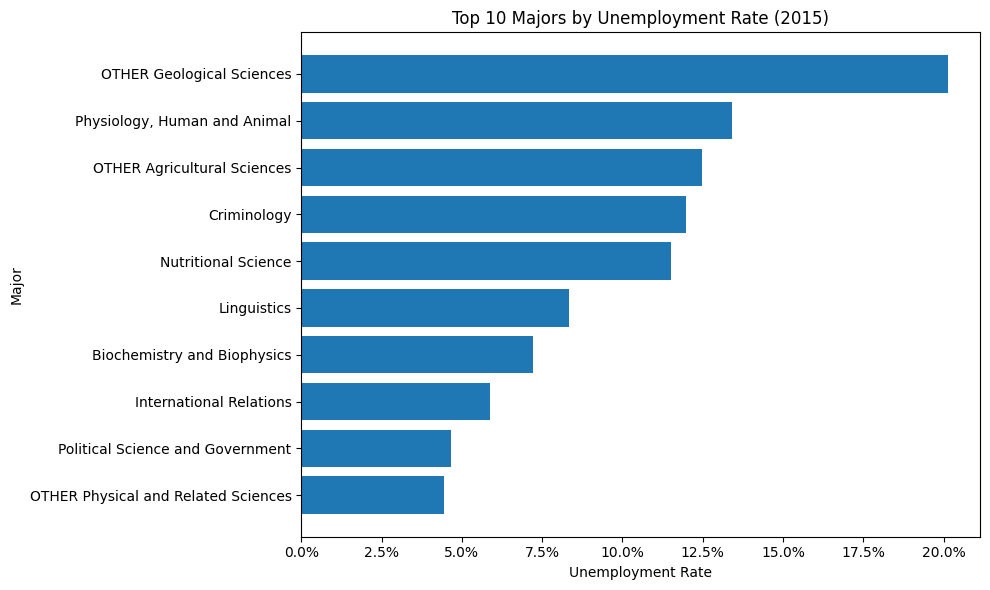

In [4]:
graduates['unemployment_rate'] = graduates['Employment.Status.Unemployed'] / (
    graduates['Employment.Status.Employed'] + graduates['Employment.Status.Unemployed']
)

graduates_2015 = graduates.loc[graduates['Year'] == 2015].copy()

top_unemployment = graduates_2015.sort_values(
    'unemployment_rate',
    ascending=False
).head(10)

print(top_unemployment[['Education.Major', 'unemployment_rate']])

plt.figure(figsize=(10, 6))
plt.barh(top_unemployment['Education.Major'], top_unemployment['unemployment_rate'])
plt.xlabel('Unemployment Rate')
plt.ylabel('Major')
plt.title('Top 10 Majors by Unemployment Rate (2015)')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout()
plt.tight_layout()
plt.savefig('images/unemployment_rate.png')
plt.show()

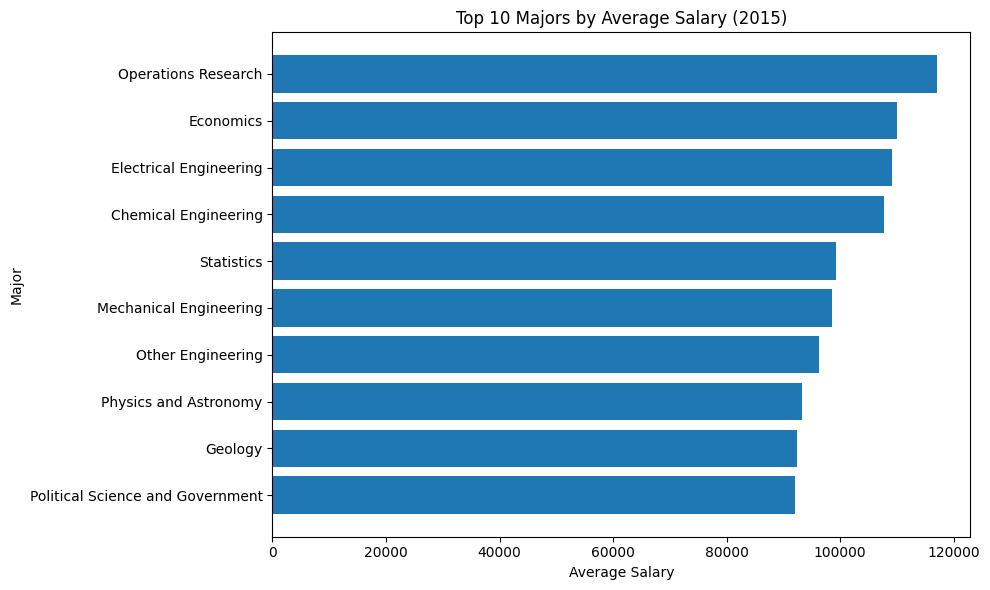

In [5]:
top_salary = graduates_2015.sort_values(
    'Salaries.Mean',
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_salary['Education.Major'], top_salary['Salaries.Mean'])
plt.xlabel('Average Salary')
plt.ylabel('Major')
plt.title('Top 10 Majors by Average Salary (2015)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.tight_layout()
plt.savefig('images/average_salary.png')
plt.show()

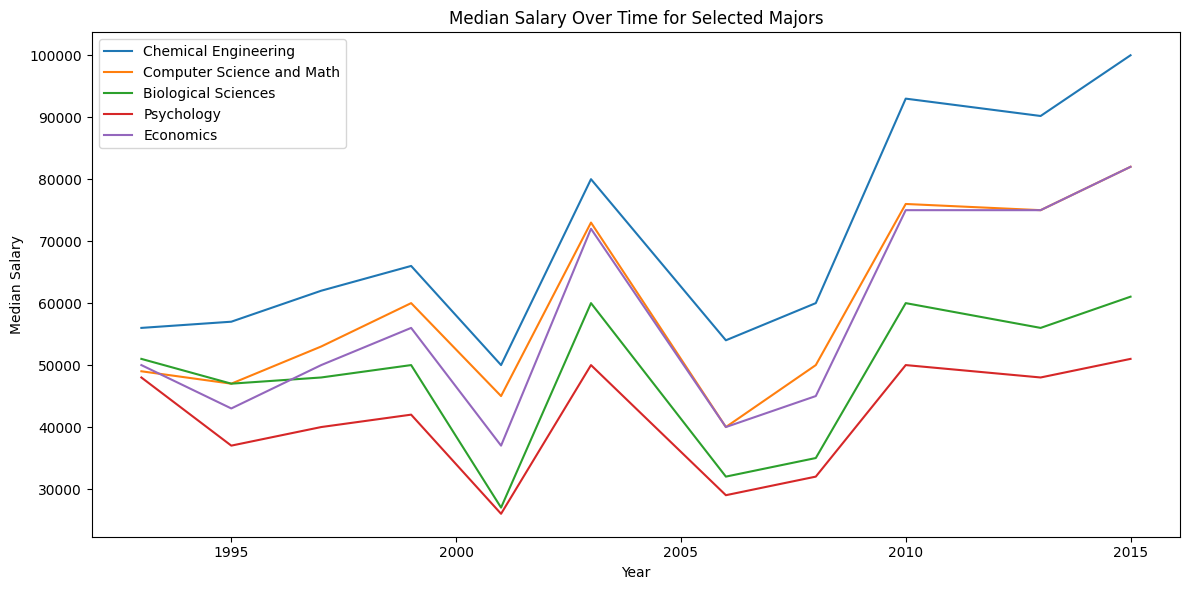

In [6]:
selected_majors = [
    'Chemical Engineering',
    'Computer Science and Math',
    'Biological Sciences',
    'Psychology',
    'Economics'
]

salary_trends = graduates.loc[
    graduates['Education.Major'].isin(selected_majors)
].copy()

plt.figure(figsize=(12, 6))

for major in selected_majors:
    major_data = salary_trends.loc[salary_trends['Education.Major'] == major]
    plt.plot(major_data['Year'], major_data['Salaries.Median'], label=major)

plt.title('Median Salary Over Time for Selected Majors')
plt.xlabel('Year')
plt.ylabel('Median Salary')
plt.legend()
plt.tight_layout()
plt.tight_layout()
plt.savefig('images/salary_trends.png')
plt.show()